Imputation: ML based technique: Matrix factorization

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Loan_Default.csv')

In [3]:
numeric_columns = df.select_dtypes(include=['number']).columns

In [4]:
print("Selected numeric columns:", numeric_columns)

Selected numeric columns: Index(['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')


In [5]:
df_imputed = df.copy()

In [6]:
df_imputed[numeric_columns] = df_imputed[numeric_columns].fillna(0)

In [7]:
print("Initial values of selected numeric columns:")
print(df_imputed[numeric_columns].head())

Initial values of selected numeric columns:
      ID  year  loan_amount  rate_of_interest  Interest_rate_spread  \
0  24890  2019       116500              0.00                0.0000   
1  24891  2019       206500              0.00                0.0000   
2  24892  2019       406500              4.56                0.2000   
3  24893  2019       456500              4.25                0.6810   
4  24894  2019       696500              4.00                0.3042   

   Upfront_charges   term  property_value   income  Credit_Score        LTV  \
0              0.0  360.0        118000.0   1740.0           758  98.728814   
1              0.0  360.0             0.0   4980.0           552   0.000000   
2            595.0  360.0        508000.0   9480.0           834  80.019685   
3              0.0  360.0        658000.0  11880.0           587  69.376900   
4              0.0  360.0        758000.0  10440.0           602  91.886544   

   Status  dtir1  
0       1   45.0  
1       1    0.0

In [8]:
n_components = len(numeric_columns)

In [9]:
svd = TruncatedSVD(n_components=n_components)
imputed_matrix = svd.fit_transform(df_imputed[numeric_columns])

In [10]:
imputed_df = pd.DataFrame(imputed_matrix, columns=[f'Component_{i}' for i in range(n_components)])

In [11]:
imputed_df.to_csv('imputed_data_matrix_factorization.csv2', index=False)

In [12]:
print("Imputed data saved to 'imputed_data_matrix_factorization.csv'")

Imputed data saved to 'imputed_data_matrix_factorization.csv'


Imputation: statistical based technique: mean based method

In [13]:
import pandas as pd
from sklearn.impute import SimpleImputer

In [14]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Loan_Default.csv')

In [15]:
numeric_columns = df.select_dtypes(include=['number']).columns

In [16]:
df_imputed = df.copy()

In [17]:
imputer = SimpleImputer(strategy='mean')
df_imputed[numeric_columns] = imputer.fit_transform(df_imputed[numeric_columns])

In [18]:
df_imputed.to_csv('imputed_data_mean.csv', index=False)

In [19]:
print("Imputed data saved to 'imputed_data_mean.csv'")

Imputed data saved to 'imputed_data_mean.csv'


Anomaly detection ML based: Isolation Forest

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier

In [21]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Loan_Default.csv')

In [22]:
numeric_columns = df.select_dtypes(include=['number']).columns

In [23]:
df_outliers = df[numeric_columns].copy()

In [24]:
df_outliers = df_outliers.fillna(-999)

In [25]:
df_outliers['is_outlier'] = -1

In [26]:
clf = HistGradientBoostingClassifier()
clf.fit(df_outliers[numeric_columns], df_outliers['is_outlier'])

HistGradientBoostingClassifier()

In [27]:
outlier_predictions = clf.predict(df_outliers[numeric_columns])

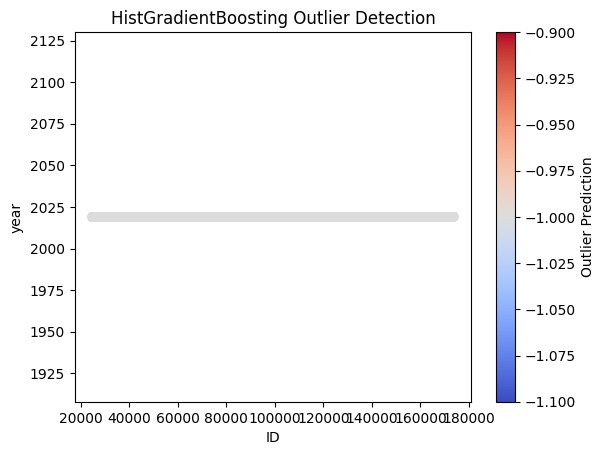

In [28]:
plt.scatter(df_outliers.iloc[:, 0], df_outliers.iloc[:, 1], c=outlier_predictions, cmap='coolwarm')
plt.xlabel(numeric_columns[0])
plt.ylabel(numeric_columns[1])
plt.title('HistGradientBoosting Outlier Detection')
plt.colorbar(label='Outlier Prediction')
plt.show()

Anomaly detection: statistical based method: Z-score based

In [30]:
import pandas as pd
import numpy as np

In [31]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Loan_Default.csv')

In [32]:
numeric_columns = df.select_dtypes(include=['number']).columns

In [33]:
df_outliers = df[numeric_columns].copy()

In [34]:
z_scores = np.abs((df_outliers - df_outliers.mean()) / df_outliers.std())

In [35]:
z_score_threshold = 2.0

In [36]:
outliers = z_scores > z_score_threshold

In [37]:
outliers.to_csv('outliers.csv', index=True)

In [38]:
print("Outliers saved to 'outliers.csv'")

Outliers saved to 'outliers.csv'


Standardization

In [111]:
import numpy as np
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/titanicdataset.csv', usecols=['Pclass', 'Age', 'Fare', 'Survived'])
df.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [112]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [101]:
df_scaled = scalar.fit_transform(df)
df_scaled

array([[-0.78927234,  0.82737724, -0.53037664, -0.50244517],
       [ 1.2669898 , -1.56610693,  0.57183099,  0.78684529],
       [ 1.2669898 ,  0.82737724, -0.25482473, -0.48885426],
       ...,
       [-0.78927234,  0.82737724,         nan, -0.17626324],
       [ 1.2669898 , -1.56610693, -0.25482473, -0.04438104],
       [-0.78927234,  0.82737724,  0.15850313, -0.49237783]])

In [102]:
pd.DataFrame(df_scaled)

,0,1,2,3
0,-0.789272,0.827377,-0.530377,-0.502445
1,1.266990,-1.566107,0.571831,0.786845
2,1.266990,0.827377,-0.254825,-0.488854
3,1.266990,-1.566107,0.365167,0.420730
4,-0.789272,0.827377,0.365167,-0.486337
...,...,...,...,...
886,-0.789272,-0.369365,-0.185937,-0.386671
887,1.266990,-1.566107,-0.737041,-0.044381
888,-0.789272,0.827377,NaN,-0.176263
889,1.266990,-1.566107,-0.254825,-0.044381


In [103]:
import matplotlib.pyplot as plt
%matplotlib inline

(array([216.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 184.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 491.]),
 array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2,
        2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. ]),
 <BarContainer object of 20 artists>)

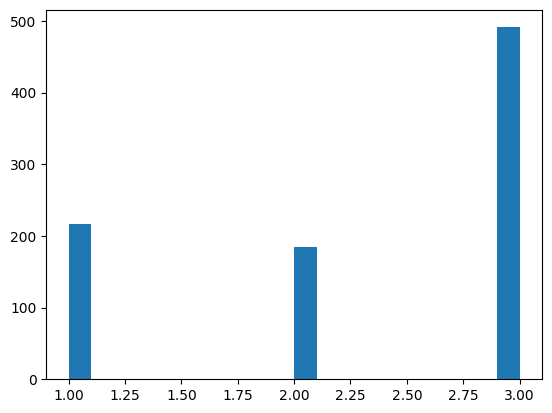

In [104]:
plt.hist(df['Pclass'],bins=20)

(array([216.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 184.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 491.]),
 array([-1.56610693, -1.44643272, -1.32675851, -1.2070843 , -1.08741009,
        -0.96773588, -0.84806167, -0.72838747, -0.60871326, -0.48903905,
        -0.36936484, -0.24969063, -0.13001642, -0.01034222,  0.10933199,
         0.2290062 ,  0.34868041,  0.46835462,  0.58802883,  0.70770304,
         0.82737724]),
 <BarContainer object of 20 artists>)

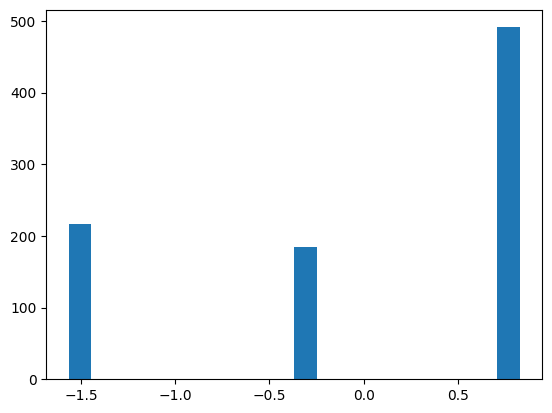

In [105]:
plt.hist(df_scaled[:,1],bins=20)

Normalization

In [106]:
from sklearn.preprocessing import MinMaxScaler
min_max = MinMaxScaler()

In [107]:
df_min_max = pd.DataFrame(min_max.fit_transform(df), columns=df.columns)
df_min_max

,Survived,Pclass,Age,Fare
0,0.0,1.0,0.271174,0.014151
1,1.0,0.0,0.472229,0.139136
2,1.0,1.0,0.321438,0.015469
3,1.0,0.0,0.434531,0.103644
4,0.0,1.0,0.434531,0.015713
...,...,...,...,...
886,0.0,0.5,0.334004,0.025374
887,1.0,0.0,0.233476,0.058556
888,0.0,1.0,NaN,0.045771
889,1.0,0.0,0.321438,0.058556


(array([216.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 184.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 491.]),
 array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2,
        2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. ]),
 <BarContainer object of 20 artists>)

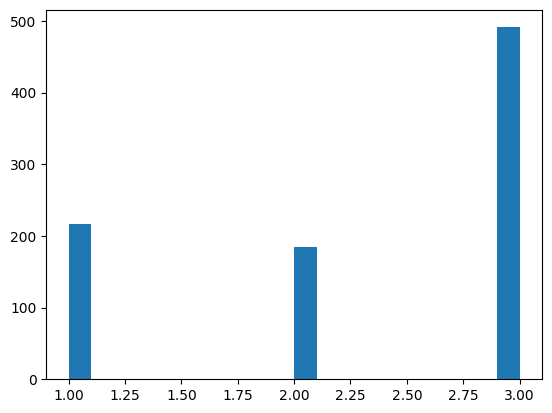

In [108]:
plt.hist(df['Pclass'],bins=20)

(array([216.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 184.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 491.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

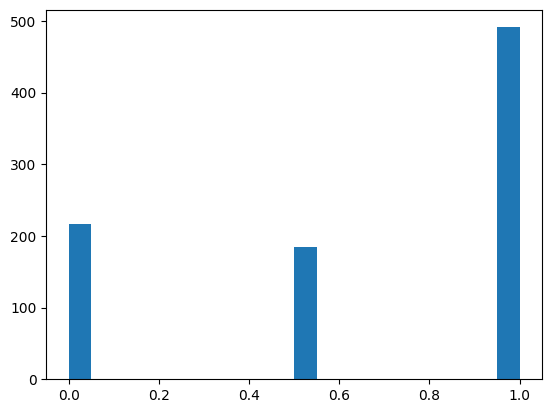

In [109]:
plt.hist(df_min_max['Pclass'],bins=20)

Encoding

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

In [79]:
df_train=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')
df_test=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')

In [80]:
print('train data set has got {} rows and {} columns'.format(df_train.shape[0],df_train.shape[1]))
print('test data set has got {} rows and {} columns'.format(df_test.shape[0],df_test.shape[1]))

train data set has got 600000 rows and 25 columns
test data set has got 400000 rows and 24 columns


In [81]:
df_train.head()

,id,bin_0,bin_1,bin_2,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,...,nom_9,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,day,month,target
0,0,0.0,0.0,0.0,F,N,Red,Trapezoid,Hamster,Russia,...,02e7c8990,3.0,Contributor,Hot,c,U,Pw,6.0,3.0,0
1,1,1.0,1.0,0.0,F,Y,Red,Star,Axolotl,NaN,...,f37df64af,3.0,Grandmaster,Warm,e,X,pE,7.0,7.0,0
2,2,0.0,1.0,0.0,F,N,Red,NaN,Hamster,Canada,...,NaN,3.0,NaN,Freezing,n,P,eN,5.0,9.0,0
3,3,NaN,0.0,0.0,F,N,Red,Circle,Hamster,Finland,...,f9d456e57,1.0,Novice,Lava Hot,a,C,NaN,3.0,3.0,0
4,4,0.0,NaN,0.0,T,N,Red,Triangle,Hamster,Costa Rica,...,c5361037c,3.0,Grandmaster,Cold,h,C,OZ,5.0,12.0,0


In [82]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 25 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      600000 non-null  int64  
 1   bin_0   582106 non-null  float64
 2   bin_1   581997 non-null  float64
 3   bin_2   582070 non-null  float64
 4   bin_3   581986 non-null  object 
 5   bin_4   581953 non-null  object 
 6   nom_0   581748 non-null  object 
 7   nom_1   581844 non-null  object 
 8   nom_2   581965 non-null  object 
 9   nom_3   581879 non-null  object 
 10  nom_4   581965 non-null  object 
 11  nom_5   582222 non-null  object 
 12  nom_6   581869 non-null  object 
 13  nom_7   581997 non-null  object 
 14  nom_8   582245 non-null  object 
 15  nom_9   581927 non-null  object 
 16  ord_0   581712 non-null  float64
 17  ord_1   581959 non-null  object 
 18  ord_2   581925 non-null  object 
 19  ord_3   582084 non-null  object 
 20  ord_4   582070 non-null  object 
 21  ord_5   58

In [83]:
X=df_train.drop(['target'],axis=1)
y=df_train['target']

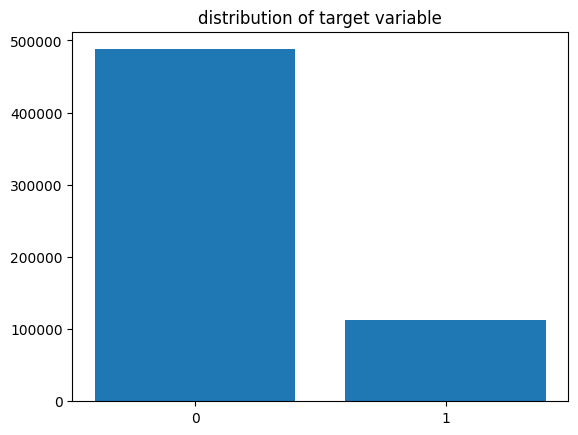

In [84]:
x=y.value_counts()
plt.bar(x.index,x)
plt.gca().set_xticks([0,1])
plt.title('distribution of target variable')
plt.show()

Method 1: Label encoding

In [92]:
import sklearn
from sklearn.preprocessing import LabelEncoder

In [86]:
%%time

train=pd.DataFrame()
label=LabelEncoder()
for c in  X.columns:
    if(X[c].dtype=='object'):
        train[c]=label.fit_transform(X[c])
    else:
        train[c]=X[c]

train.head(3)

CPU times: user 1.46 s, sys: 3.34 ms, total: 1.47 s
Wall time: 1.48 s


,id,bin_0,bin_1,bin_2,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,...,nom_8,nom_9,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,day,month
0,0,0.0,0.0,0.0,0,0,2,4,3,5,...,1,27,3.0,0,3,2,20,56,6.0,3.0
1,1,1.0,1.0,0.0,0,1,2,3,0,6,...,69,2112,3.0,2,5,4,23,150,7.0,7.0
2,2,0.0,1.0,0.0,0,0,2,6,3,0,...,102,2218,3.0,5,2,13,15,105,5.0,9.0


In [87]:
print('train data set has got {} rows and {} columns'.format(train.shape[0],train.shape[1]))

train data set has got 600000 rows and 24 columns


In [88]:
def logistic(X,y):
    X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)
    lr=LogisticRegression()
    lr.fit(X_train,y_train)
    y_pre=lr.predict(X_test)
    print('Accuracy : ',accuracy_score(y_test,y_pre))

In [115]:
logistic(train,y)

Accuracy :  0.8229583333333333


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Method 2 : One hot encoding

In [96]:
from sklearn.preprocessing import OneHotEncoder

In [97]:
%%time

one=OneHotEncoder()

one.fit(X)
train=one.transform(X)

print('train data set has got {} rows and {} columns'.format(train.shape[0],train.shape[1]))

train data set has got 600000 rows and 605723 columns
CPU times: user 3.19 s, sys: 123 ms, total: 3.31 s
Wall time: 3.99 s


In [98]:
logistic(train,y)

Accuracy :  0.8229583333333333


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
